In [63]:
import pandas as pd
import re
from pathlib import Path
import glob
import os
import numpy as np
import skimage
import itertools
import matplotlib.pyplot as plt
from skimage.io import imread

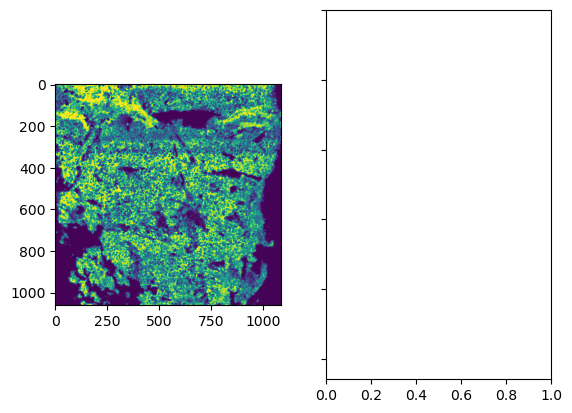

In [88]:
def load_and_enhance(name):
    img = skimage.io.imread(name)
    p2, p98 = np.percentile(img, (2, 98))
    img = skimage.exposure.rescale_intensity(img,in_range=(p2,p98), out_range = (0,.999))#added out_range to something <1 because otherwise rounding >1
    img = skimage.exposure.equalize_adapthist(img,clip_limit=0.01)
    return img

base_dir = '../../Img_Denoised/non_preprocessed/'
file_pattern = '*.tiff'  # Change to '*.tif' if your files have the '.tif' extension

sub_dir_pattern = os.path.join(base_dir, 'Leap*')
paths = glob.glob(os.path.join(sub_dir_pattern, file_pattern), recursive=True)
filename= Path(base_dir,'Leap001_8','CD8a.tiff')
img = load_func=load_and_enhance(filename)

f,axs = plt.subplots(ncols = 2,sharey = True)
axs[0].imshow(img)




Visualise the effect of our preprocessing pipeline.
Log1p of original image, after denoising (center) and our finally processed image (right)

'Leap066_14/CD4.tiff'

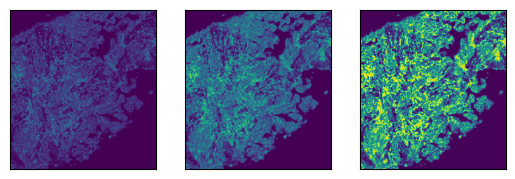

In [104]:
base_dir = '../../Img_Denoised/non_preprocessed/'
file_pattern = '*.tiff'  # Change to '*.tif' if your files have the '.tif' extension
ending = 'Leap066_14/CD4.tiff'

f,axs = plt.subplots(ncols =3)
axs[0].imshow(np.log1p(imread(Path('../../split_channels_nohpf/',ending))))
axs[1].imshow(np.log1p(imread(Path('../../Img_Denoised/non_preprocessed/',ending))))
axs[2].imshow(imread(Path('../../Img_Denoised/contrast_adj/',ending)))
#now skip denoise but do log transform and CLAHE
'''
img = imread(imgs.files[i])
p2, p98 = np.percentile(img, (0, 98))
#img = skimage.exposure.rescale_intensity(img,in_range=(p2,p98), out_range = (0,.999))#added out_range to something <1 because otherwise rounding >1
img = skimage.exposure.rescale_intensity(img,in_range=(p2,p98), out_range = (0,.999))
img = skimage.exposure.equalize_adapthist(img,clip_limit=0.01)
axs[1,1].imshow(img)
'''
for ax in axs:
    ax.set_xticks([])
    ax.set_yticks([])
ending

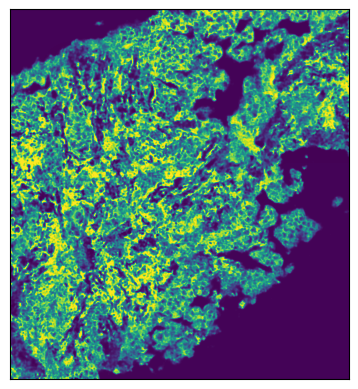

In [118]:
plt.imshow(np.log1p(imread(Path('../../split_channels_nohpf/',ending))))
plt.xticks([])
plt.yticks([])
plt.savefig('figures/raw.png',transparent = True)
plt.imshow(np.log1p(imread(Path('../../Img_Denoised/non_preprocessed/',ending))))
plt.xticks([])
plt.yticks([])
plt.savefig('figures/denoised.png',transparent = True)
plt.imshow(imread(Path('../../Img_Denoised/contrast_adj/',ending)))
plt.xticks([])
plt.yticks([])
plt.savefig('figures/final.png',transparent = True)

(array([4.94834e+05, 1.65499e+05, 3.47140e+04, 1.17520e+04, 3.92100e+03,
        1.29200e+03, 4.18000e+02, 1.64000e+02, 4.80000e+01, 1.40000e+01]),
 array([7.01921387e-03, 1.55414438e+00, 3.10126972e+00, 4.64839506e+00,
        6.19551992e+00, 7.74264526e+00, 9.28977013e+00, 1.08368959e+01,
        1.23840208e+01, 1.39311466e+01, 1.54782715e+01]),
 <BarContainer object of 10 artists>)

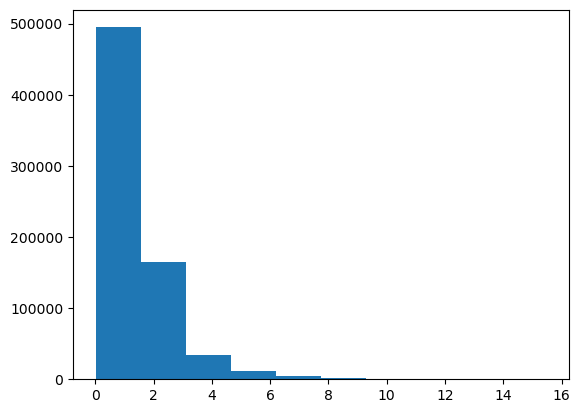

In [103]:
img = imread(Path('../../Img_Denoised/non_preprocessed/',ending))
plt.hist(img.reshape(-1))